# 质量动量因子

区别于简单涨幅排名，本因子将趋势强度与趋势稳定性结合：`score = annual_ret × R²`。其中，`annual_ret` 来自收盘价对数的线性趋势斜率，衡量趋势方向和强度；`R²` 衡量这条趋势线对窗口内价格路径的解释程度。

- **示例代码版**：使用 26 个收盘价、`1 → 2` 线性权重，并严格保留原示例的 `np.polyfit` 和 R² 口径。
- **63 日半衰期版**：使用指数观测权重、标准加权最小二乘和加权均值 R²，作为对照。

因子包含当日收盘价：在 t 日收盘后可得到 t 日因子值，并据此在 t+1 起持有。`analyze_factor` 以 t+1 及之后的收益评价 t 日因子，因此不会把已在 t 日收盘前发生的收益误计为因子收益，也不会产生前视。

两个版本只在权重及 R² 的统计口径上不同，均输出年化趋势收益、R² 和二者乘积，便于将“近期趋势更重要”的半衰期设定与原示例设定作可比对照。

In [9]:
# 获取数据与因子参数。所有日期均按交易日数据的实际可得范围处理。
%reload_ext autoreload
%autoreload 2
import sys

sys.path.append(r'C:\Users\20561\Desktop\策略')
from my_utils.fun import read_day_data
from 因子回测.alpha import analyze_factor
import polars as pl
import numpy as np
import datetime as dt

# start_date / end_date：回测评价区间；因子计算会额外读取此前数据作为滚动窗口预热。
start_date = dt.date(2021, 1, 1)
end_date = dt.date(2026, 8, 1)
# window：每个因子值使用的最近收盘价数量（含当日）。
window = 26
# annualization：将每交易日对数趋势斜率换算成年化简单收益时采用的交易日数。
annualization = 250
# half_life：半衰期版中，观测值权重衰减至最新值一半所需的交易日数。
half_life = 63.0

# 预热数据只用于形成分析首日的完整 26 日价格窗口；最终会在构造 analysis_data 时剔除。
data_start_date = start_date - dt.timedelta(days=60)
stock_data = read_day_data(
    start_date=data_start_date,
    end_date=end_date,
    fields=['trading_date', 'code', 'close', 'pre_close'],
)


In [10]:
def quality_momentum_weights(
    window: int,
    mode: str,
    half_life: float = 63.0,
) -> np.ndarray:
    """生成从最早到最新观测值的回归/拟合权重。

    example：严格复现原示例的 1→2 线性权重。传给 np.polyfit 时，
    该权重会被平方后进入残差平方和；因此它不是标准 WLS 的观测权重。
    halflife：最新价格权重为 1，越早的价格按半衰期指数递减，可直接作为
    标准 WLS 的观测权重。
    """
    if window < 2:
        raise ValueError('window 必须大于等于 2')
    if half_life <= 0:
        raise ValueError('half_life 必须大于 0')
    if mode == 'example':
        # np.linspace 的顺序与价格窗口一致：末端（最新收盘价）获得较大权重。
        return np.linspace(1.0, 2.0, window)
    if mode == 'halflife':
        # age=0 对应最新值，故最新值权重恒为 1；最早值的 age 最大。
        age = np.arange(window - 1, -1, -1, dtype=float)
        return 0.5 ** (age / half_life)
    raise ValueError("mode 必须是 'example' 或 'halflife'")


def calc_momentum_score(
    prices,
    mode: str = 'example',
    annualization: int = 250,
    half_life: float = 63.0,
) -> tuple[float, float, float]:
    """计算单个价格窗口的趋势强度、稳定性及最终得分。

    返回 (annual_ret, r2, score)。先对价格取自然对数，再拟合 y=a*x+b：
    - annual_ret = expm1(a * annualization)，把每交易日对数斜率转为年化简单收益；
    - r2 反映价格路径偏离直线趋势的程度；
    - score = annual_ret * r2，使杂乱波动的趋势获得较低权重。

    本函数用于清晰表达计算口径和单窗口校验；批量生产计算由
    _calculate_momentum_windows 使用等价的向量化公式完成。
    """
    prices = np.asarray(prices, dtype=float)
    if prices.ndim != 1:
        raise ValueError('prices 必须是一维价格序列')

    # 先校验参数并生成权重；空值、无穷值和非正价格均无法取对数。
    weights = quality_momentum_weights(len(prices), mode, half_life)
    if not np.isfinite(prices).all() or np.any(prices <= 0):
        return np.nan, np.nan, np.nan

    # 对数价格下，指数增长对应一条直线，回归斜率可直接解释为单日对数收益。
    y = np.log(prices)
    if np.ptp(y) <= 1e-12:
        return 0.0, 0.0, 0.0

    # x 只表示窗口内的相对时间位置；真实日期间隔不参与回归。
    x = np.arange(len(y), dtype=float)
    # np.polyfit 的 w 会最小化 Σ(w·残差)²：
    # - 示例版保留原始 w=weights，因此残差实际按 weights² 加权；
    # - 半衰期版传入 sqrt(weights)，使目标函数为标准 WLS 的 Σ(weights·残差²)。
    fit_weights = weights if mode == 'example' else np.sqrt(weights)
    slope, intercept = np.polyfit(x, y, deg=1, w=fit_weights)
    # 用 expm1 保持小斜率下的数值精度，并将对数累计收益转换为简单收益。
    annual_ret = np.expm1(slope * annualization)
    y_fit = np.polyval([slope, intercept], x)

    # R² = 1 - SS_res / SS_tot。示例版沿用原始的非加权中心；
    # 半衰期版使用与回归一致的加权中心，令两个平方和的统计口径一致。
    center = y.mean() if mode == 'example' else np.average(y, weights=weights)
    ss_res = np.sum(weights * (y - y_fit) ** 2)
    ss_tot = np.sum(weights * (y - center) ** 2)
    r2 = 0.0 if ss_tot <= 1e-10 else 1.0 - ss_res / ss_tot
    if mode == 'halflife':
        # 标准 WLS 下理论 R² 位于 [0, 1]；裁剪可消除极小的浮点越界。
        r2 = float(np.clip(r2, 0.0, 1.0))

    return float(annual_ret), float(r2), float(annual_ret * r2)


def _calculate_momentum_windows(
    price_windows: np.ndarray,
    mode: str,
    annualization: int,
    half_life: float,
) -> np.ndarray:
    """批量计算同一只股票的全部滚动窗口。

    输入形状为 (窗口个数, window)。本函数把单窗口回归写成加权最小二乘的
    闭式解，在 NumPy 中一次性计算所有窗口，避免 Polars map_groups 内逐行调用
    Python 函数造成的性能瓶颈。输出三列顺序固定为 annual_ret、r2、score。
    """
    window_size = price_windows.shape[1]
    # 预先填充 NaN，使含缺失、无穷或非正价格的窗口自然保留为空，
    # 而不会影响同一股票中其余有效窗口。
    metrics = np.full((len(price_windows), 3), np.nan, dtype=float)
    valid = np.isfinite(price_windows).all(axis=1) & (price_windows > 0).all(axis=1)
    if not np.any(valid):
        return metrics

    # 仅对有效窗口取对数；此处的每一行仍对应一个原始滚动窗口。
    y = np.log(price_windows[valid])
    x = np.arange(window_size, dtype=float)
    weights = quality_momentum_weights(window_size, mode, half_life)
    # 统一改写为加权最小二乘的闭式解：
    # 示例版与 np.polyfit(w=weights) 等价，观测权重实际为 weights²；
    # 半衰期版的 weights 本身就是标准 WLS 的观测权重。
    regression_weights = weights**2 if mode == 'example' else weights
    weight_sum = regression_weights.sum()
    x_mean = np.sum(regression_weights * x) / weight_sum
    x_centered = x - x_mean
    denominator = np.sum(regression_weights * x_centered**2)

    # 斜率 = Σ[w·(x-x̄)·y] / Σ[w·(x-x̄)²]；广播后一次得到所有窗口的结果。
    slopes = np.sum(y * (regression_weights * x_centered), axis=1) / denominator
    intercepts = (
        np.sum(y * regression_weights, axis=1) / weight_sum - slopes * x_mean
    )
    fitted = slopes[:, None] * x + intercepts[:, None]
    annual_ret = np.expm1(slopes * annualization)

    # R² 的总离差中心须与各版本既定口径一致，不能为统一写法而改变示例结果。
    centers = (
        y.mean(axis=1)
        if mode == 'example'
        else np.sum(y * weights, axis=1) / weights.sum()
    )
    ss_res = np.sum(weights * (y - fitted) ** 2, axis=1)
    ss_tot = np.sum(weights * (y - centers[:, None]) ** 2, axis=1)
    r2 = np.zeros(len(y), dtype=float)
    non_constant = ss_tot > 1e-10
    r2[non_constant] = 1.0 - ss_res[non_constant] / ss_tot[non_constant]

    # 常数价格窗口没有可解释的趋势或波动：将受浮点误差影响的斜率、R²、得分统一归零。
    constant = np.ptp(y, axis=1) <= 1e-12
    annual_ret[constant] = 0.0
    r2[constant] = 0.0
    if mode == 'halflife':
        r2 = np.clip(r2, 0.0, 1.0)

    metrics[valid] = np.column_stack((annual_ret, r2, annual_ret * r2))
    return metrics


def add_quality_momentum_factors(
    data: pl.DataFrame,
    window: int = 26,
    annualization: int = 250,
    half_life: float = 63.0,
) -> pl.DataFrame:
    """按股票、按日期追加两套质量动量因子。

    数据必须包含 code、trading_date、close。每只股票独立排序并构造滚动窗口，
    所以不会把不同股票的价格拼接到同一个窗口。首个 window-1 交易日没有足够
    历史价格，因子保持空值；含异常价格的任一窗口同样保持空值。
    """
    required = {'code', 'trading_date', 'close'}
    missing = sorted(required.difference(data.columns))
    if missing:
        raise ValueError('缺少必要列: ' + ', '.join(missing))
    # 在计算前统一触发参数校验，避免数据量较小时非法参数被静默跳过。
    quality_momentum_weights(window, 'example', half_life)

    mode_columns = {
        'example': ('momentum_annual_ret', 'momentum_r2', 'momentum_score'),
        'halflife': (
            'momentum_annual_ret_halflife',
            'momentum_r2_halflife',
            'momentum_score_halflife',
        ),
    }

    # 列名集中维护，确保两个版本的输出顺序与 _calculate_momentum_windows 一一对应。
    def add_group(group: pl.DataFrame) -> pl.DataFrame:
        # group 是单只股票。显式排序可避免源数据顺序影响滚动窗口的时间方向。
        group = group.sort('trading_date')
        output = {
            column: np.full(group.height, np.nan, dtype=float)
            for columns in mode_columns.values()
            for column in columns
        }
        if group.height >= window:
            # sliding_window_view 不复制原始价格数组；第一个窗口对应第 window-1 行。
            price_windows = np.lib.stride_tricks.sliding_window_view(
                group['close'].to_numpy(), window_shape=window
            )
            for mode, columns in mode_columns.items():
                metrics = _calculate_momentum_windows(
                    price_windows, mode, annualization, half_life
                )
                for metric_index, column in enumerate(columns):
                    # 前 window-1 行无完整窗口；其后每行与同位置的滚动结果对齐。
                    output[column][window - 1:] = metrics[:, metric_index]

        return group.with_columns(
            [pl.Series(column, values) for column, values in output.items()]
        )

    factor_columns = [
        column for columns in mode_columns.values() for column in columns
    ]
    return (
        data.sort('code', 'trading_date')
        .group_by('code', maintain_order=True)
        .map_groups(add_group)
        # 对外统一以 null 表示不可用因子，便于后续 drop_nulls；不保留 NumPy 的 NaN。
        .with_columns([pl.col(column).fill_nan(None) for column in factor_columns])
        .sort('code', 'trading_date')
    )


stock_data = add_quality_momentum_factors(
    stock_data,
    window=window,
    annualization=annualization,
    half_life=half_life,
)

# 将计算结果整理为 analyze_factor 所需的截面面板。
# daily_ret[t] 是 t-1 收盘到 t 收盘的个股简单收益；它仅作为收益序列输入。
# analyze_factor 会把 t 日因子与 t+1 及之后的收益匹配，因此 t 日已实现的 daily_ret
# 不会被计入 t 日信号的收益，符合“收盘得到信号、下一交易日开始持有”的时点。
analysis_data = (
    stock_data.with_columns(
        (pl.col('close') / pl.col('pre_close') - 1).alias('daily_ret')
    )
    # 预热期只服务于窗口构造；进入评价区间前统一剔除，避免影响样本统计。
    .filter(pl.col('trading_date').is_between(start_date, end_date))
    .select(
        'trading_date',
        'code',
        'momentum_annual_ret',
        'momentum_r2',
        'momentum_score',
        'momentum_annual_ret_halflife',
        'momentum_r2_halflife',
        'momentum_score_halflife',
        'daily_ret',
    )
    # 这里同时要求两版得分均可用，保证两套回测使用完全相同的股票—日期样本。
    .drop_nulls(['momentum_score', 'momentum_score_halflife', 'daily_ret'])
    .filter(
        pl.col('momentum_score').is_finite()
        & pl.col('momentum_score_halflife').is_finite()
        & pl.col('daily_ret').is_finite()
    )
    # 以当日样本股票的等权平均收益构造横截面基准，用于分组净值的相对比较。
    .with_columns(
        pl.col('daily_ret').mean().over('trading_date').alias('benchmark_ret')
    )
)

analysis_data.head()


trading_date,code,momentum_annual_ret,momentum_r2,momentum_score,momentum_annual_ret_halflife,momentum_r2_halflife,momentum_score_halflife,daily_ret,benchmark_ret
date,str,f64,f64,f64,f64,f64,f64,f64,f64
2021-01-04,"""SHSE.600000""",-0.477453,0.769195,-0.367254,-0.514666,0.783275,-0.403125,0.001033,0.014412
2021-01-05,"""SHSE.600000""",-0.433152,0.69806,-0.302366,-0.482753,0.720299,-0.347726,-0.001032,-0.000934
2021-01-06,"""SHSE.600000""",-0.366422,0.551353,-0.202028,-0.441955,0.59968,-0.265031,0.014463,-0.012799
2021-01-07,"""SHSE.600000""",-0.276748,0.393666,-0.108946,-0.367582,0.459408,-0.16887,-0.001018,-0.0255
2021-01-08,"""SHSE.600000""",-0.178637,0.227079,-0.040565,-0.283175,0.305256,-0.086441,0.002039,-0.000938



===== 示例代码版：momentum_score =====


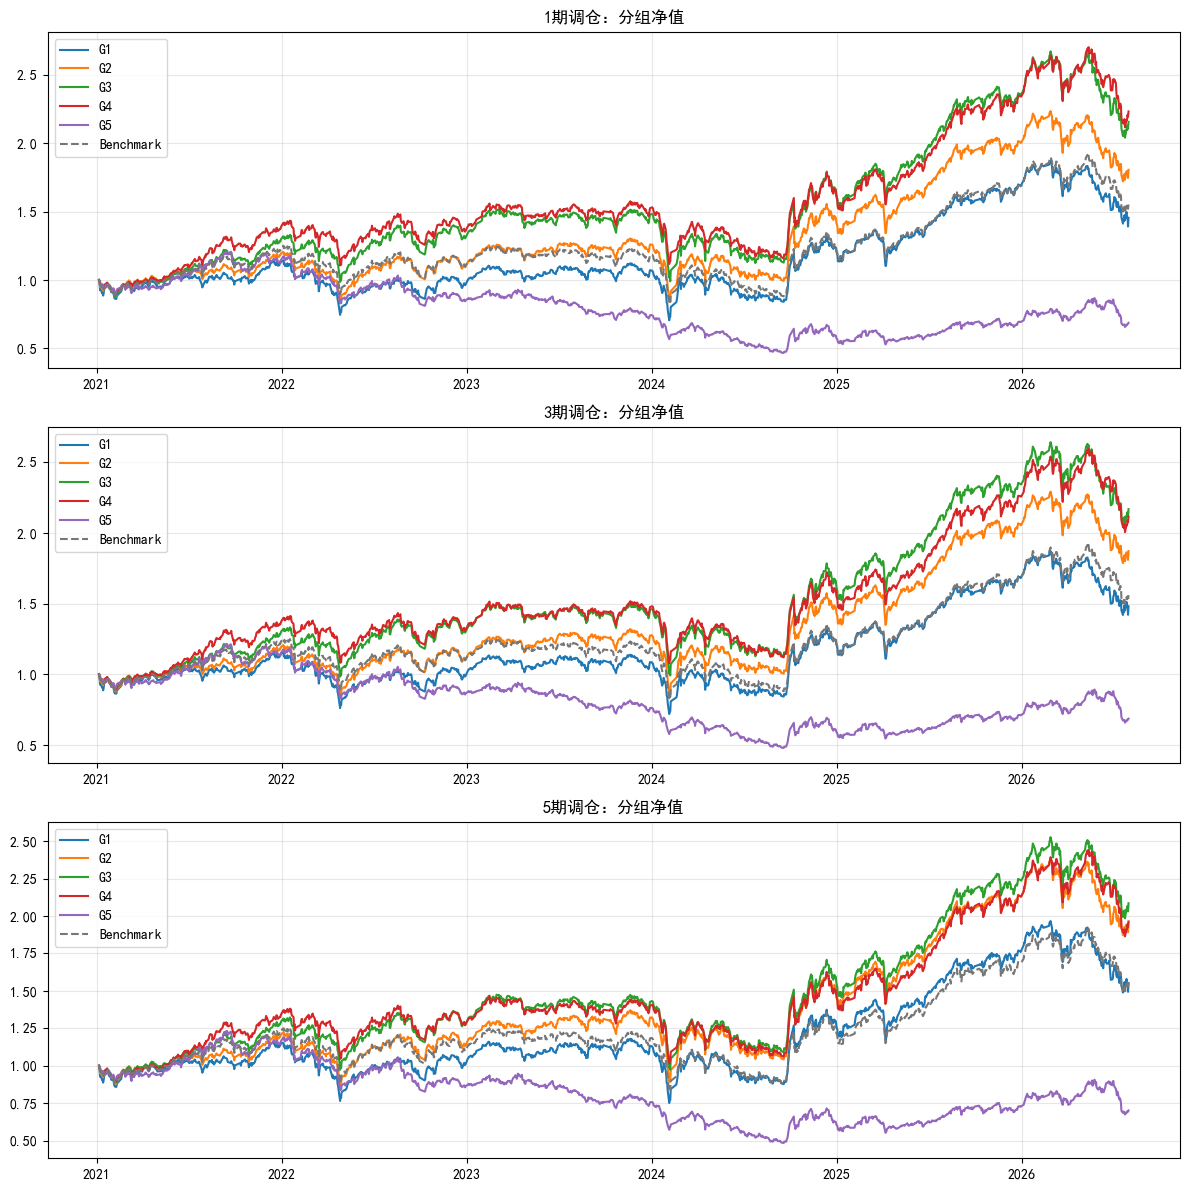

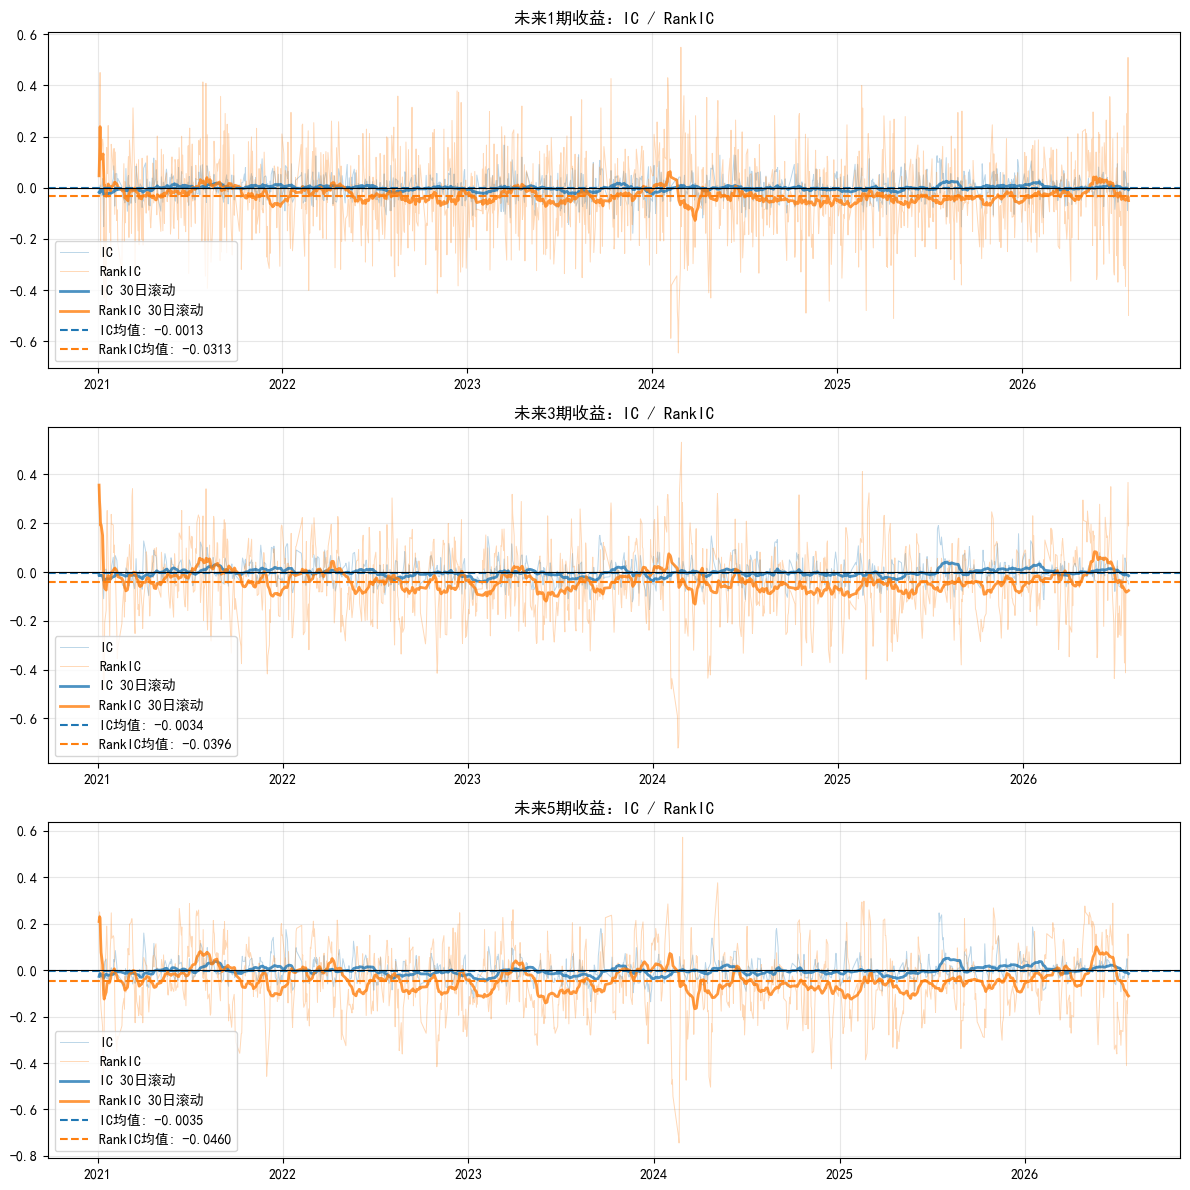

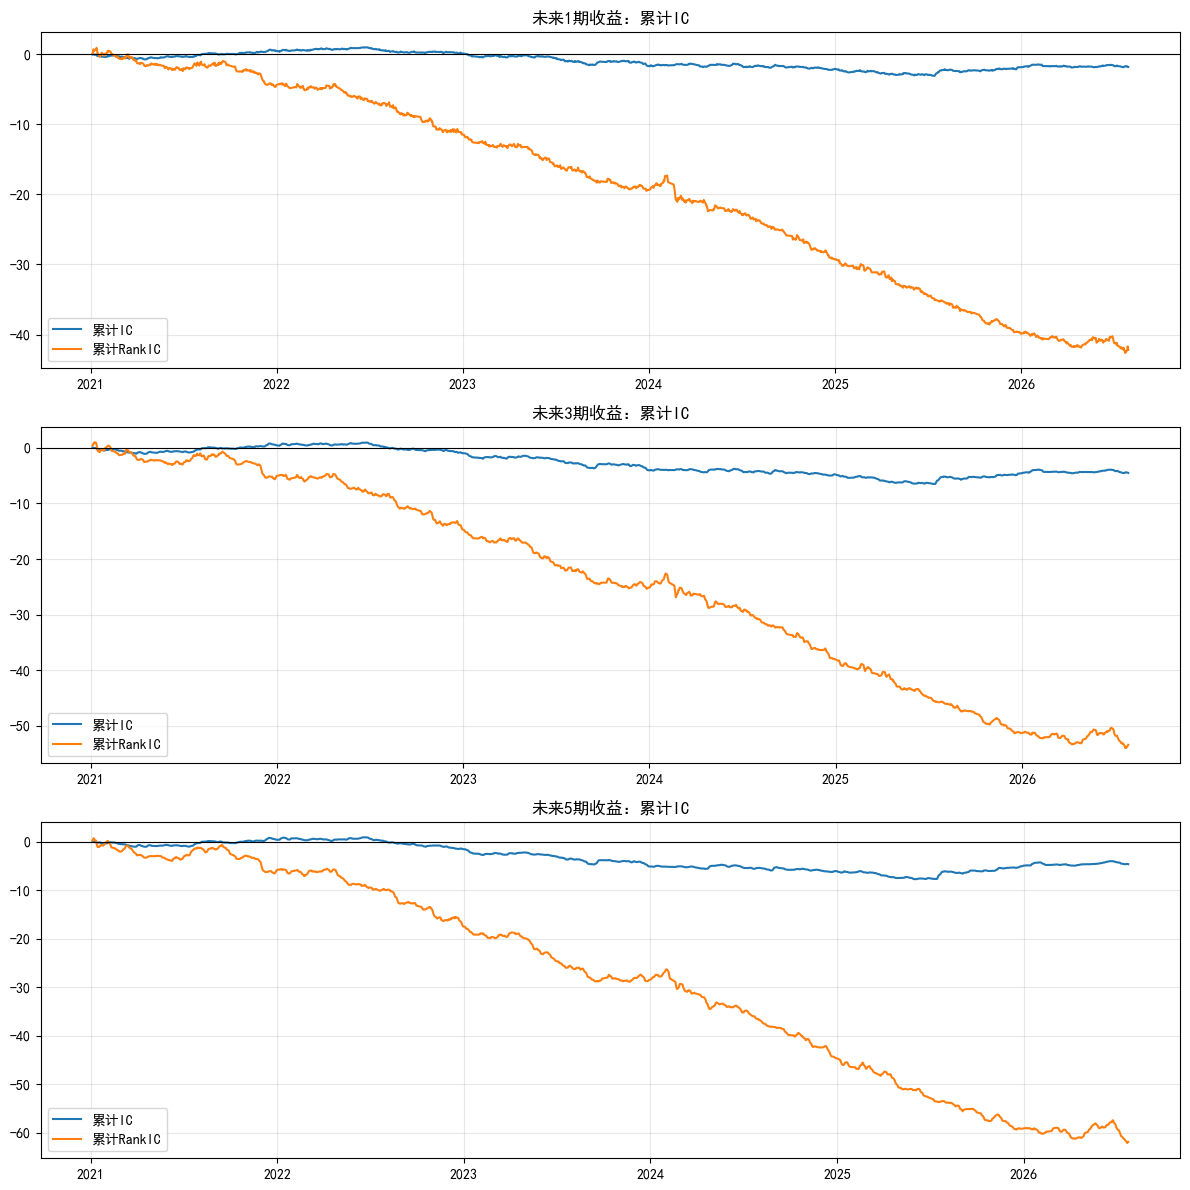


===== 63日半衰期版：momentum_score_halflife =====


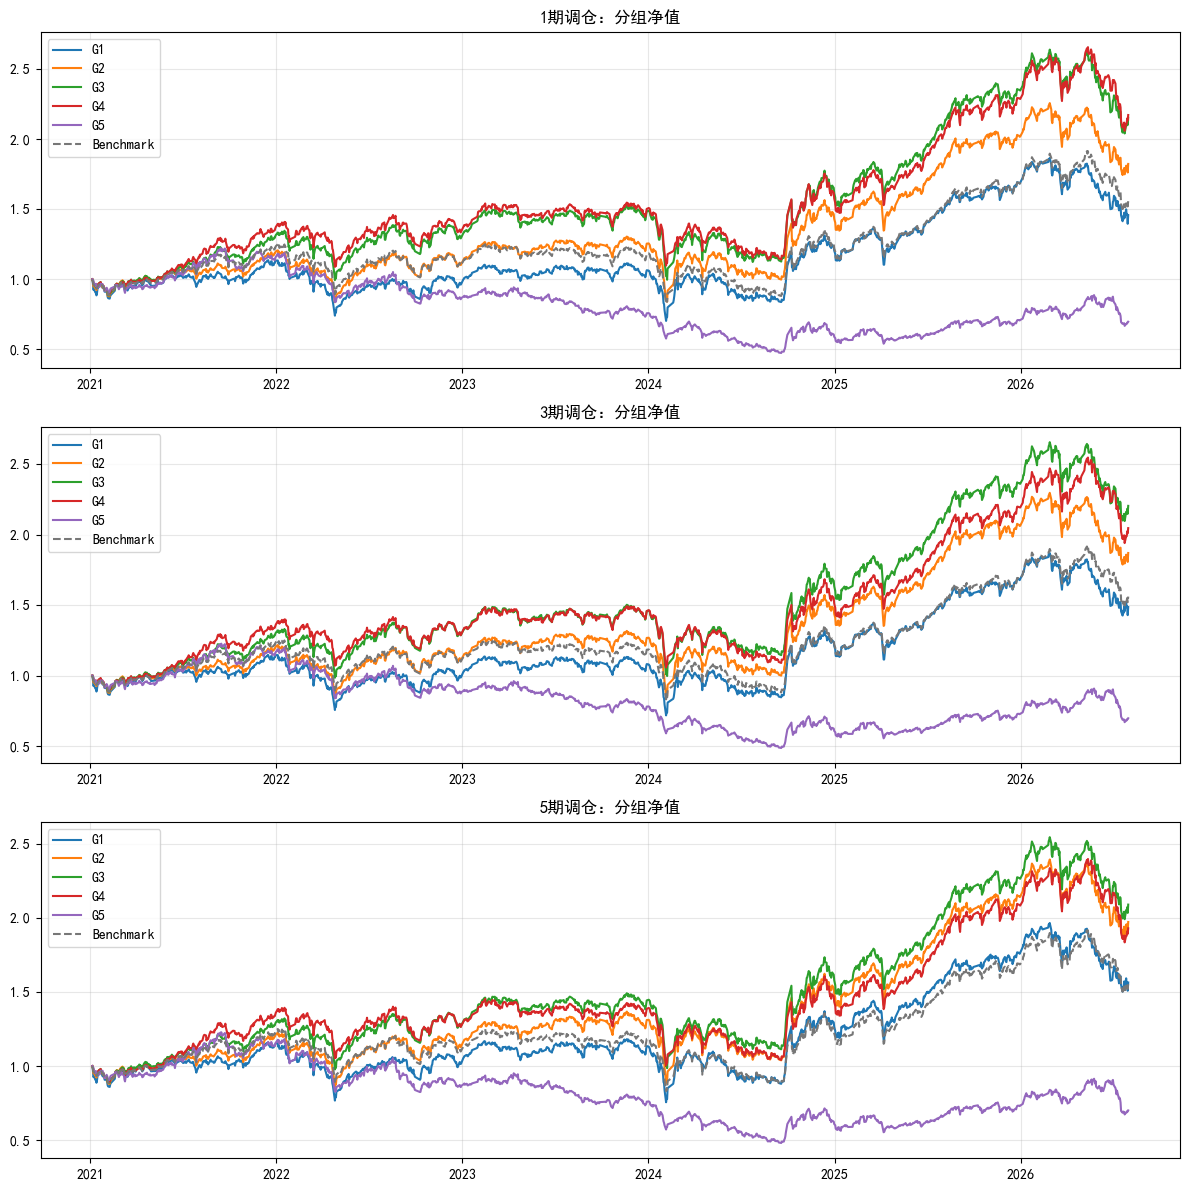

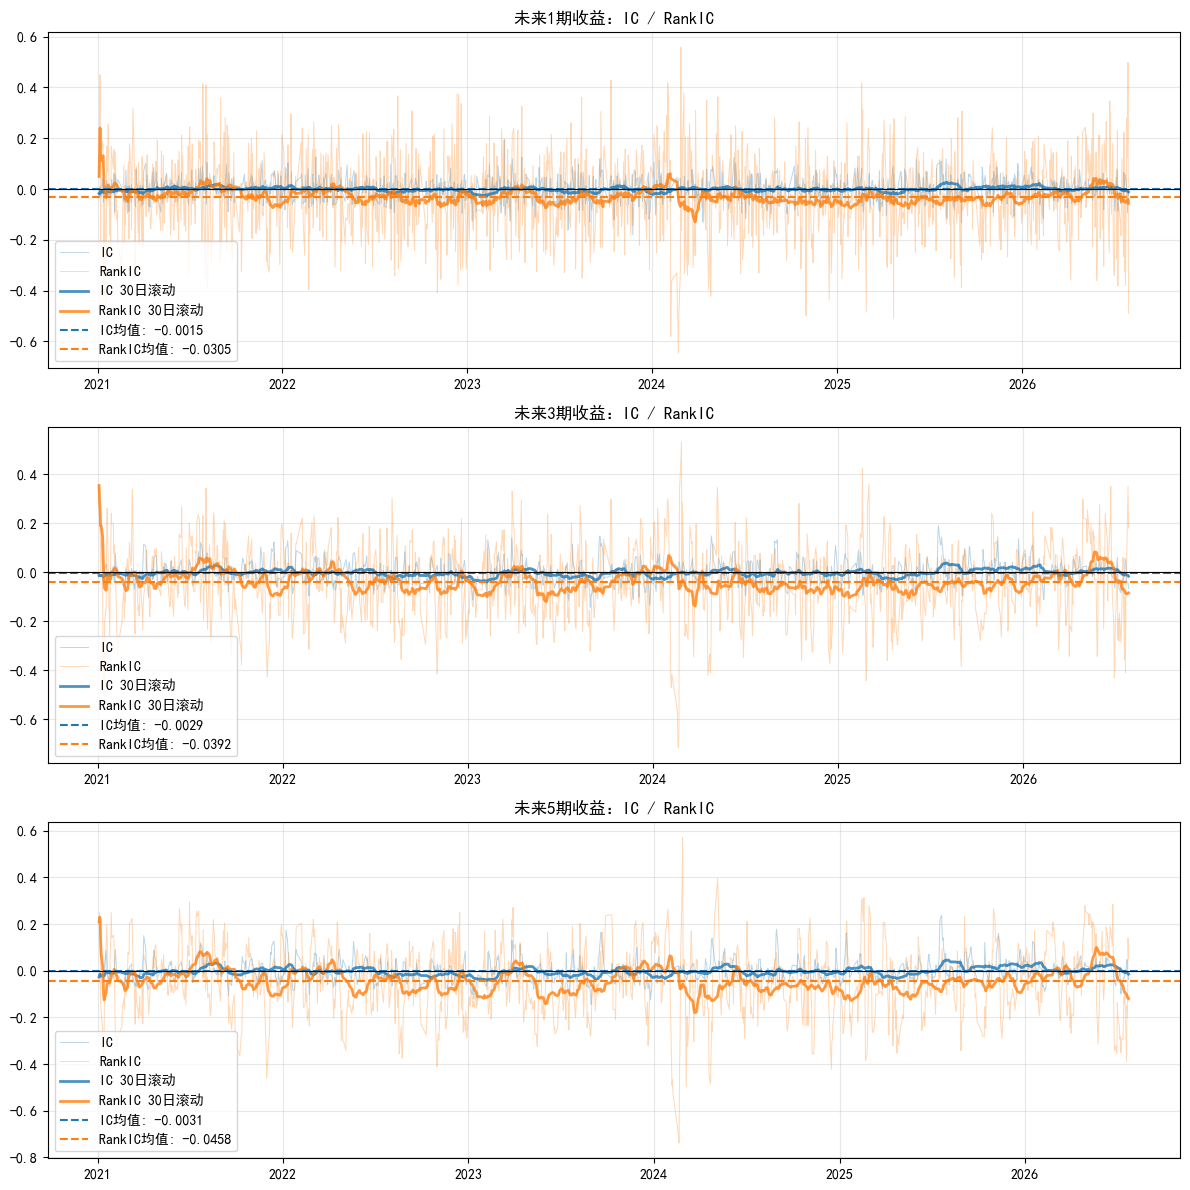

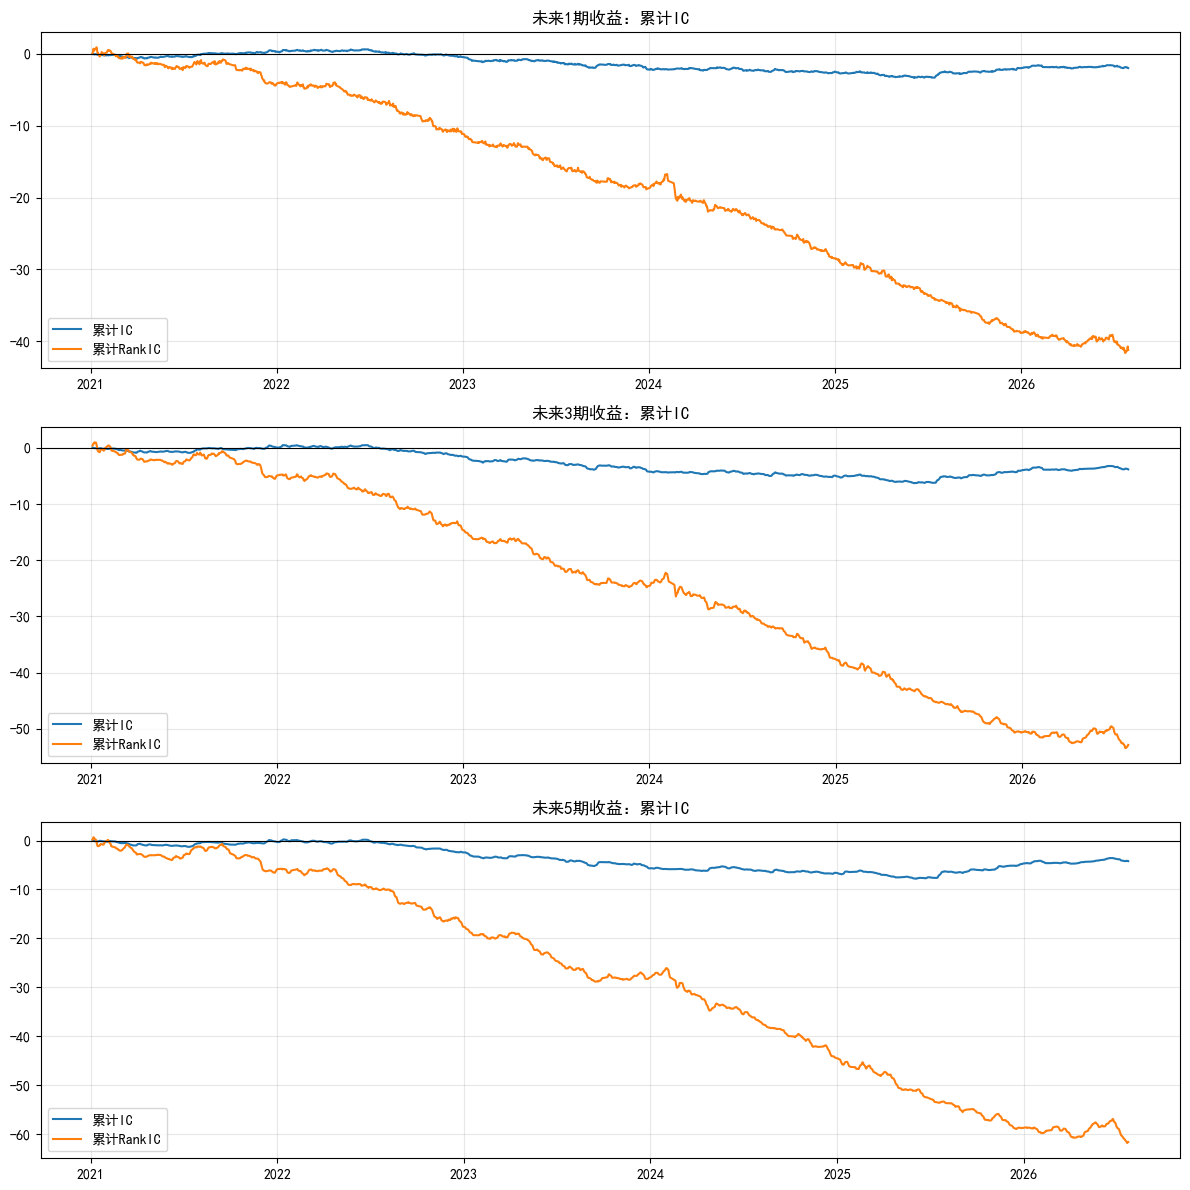

{'示例代码版': {'ic_stats': shape: (3, 9)
  ┌────────┬───────────┬──────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
  │ window ┆ ic_mean   ┆ ic_std   ┆ ic_positiv ┆ … ┆ rank_ic_st ┆ rank_ic_po ┆ ic_ir     ┆ rank_ic_i │
  │ ---    ┆ ---       ┆ ---      ┆ e_ratio    ┆   ┆ d          ┆ sitive_rat ┆ ---       ┆ r         │
  │ i32    ┆ f64       ┆ f64      ┆ ---        ┆   ┆ ---        ┆ io         ┆ f64       ┆ ---       │
  │        ┆           ┆          ┆ f64        ┆   ┆ f64        ┆ ---        ┆           ┆ f64       │
  │        ┆           ┆          ┆            ┆   ┆            ┆ f64        ┆           ┆           │
  ╞════════╪═══════════╪══════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
  │ 1      ┆ -0.001339 ┆ 0.04597  ┆ 0.477778   ┆ … ┆ 0.159996   ┆ 0.4        ┆ -0.029122 ┆ -0.195352 │
  │ 3      ┆ -0.003363 ┆ 0.046425 ┆ 0.421365   ┆ … ┆ 0.150194   ┆ 0.401335   ┆ -0.072439 ┆ -0.263728 │
  │ 5      ┆ -0.00347  ┆ 0.046214 ┆ 

In [11]:
# 两套因子完全复用同一收益窗口、分组数和分析流程，差异仅来自因子构造口径。
factor_columns = {
    '示例代码版': 'momentum_score',
    '63日半衰期版': 'momentum_score_halflife',
}
factor_results = {}

for factor_name, factor_col in factor_columns.items():
    # analyze_factor 内部使用未来收益计算 IC 和分组表现；ret_windows 表示持有期长度。
    print(f'\n===== {factor_name}：{factor_col} =====')
    factor_results[factor_name] = analyze_factor(
        data=analysis_data,
        factor_col=factor_col,
        ret_col='daily_ret',
        ret_windows=[1, 3, 5],
        ic_windows=[1, 3, 5],
        # 每个交易日按因子值从低到高分为五组，G1/G5 的方向以 analyze_factor 输出为准。
        group_num=5,
        plot=True,
        save_result=False,
    )

{
    factor_name: {
        'ic_stats': result['ic_stats'],
        'group_stats': result['group_stats'],
    }
    for factor_name, result in factor_results.items()
}
